In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/customer_shopping_behavior.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (3900, 18)

First 5 rows:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [2]:
# Check data types and basic info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used    

In [3]:
# Standardize column names (lowercase, replace spaces with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Confirm new column names
print("=== Cleaned Column Names ===")
print(df.columns.tolist())

=== Cleaned Column Names ===
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


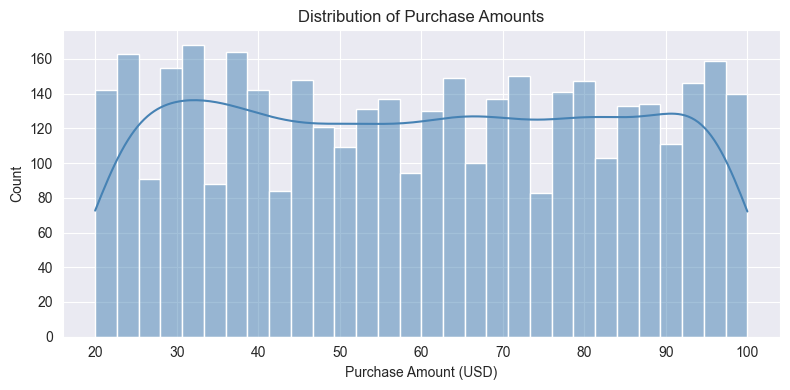

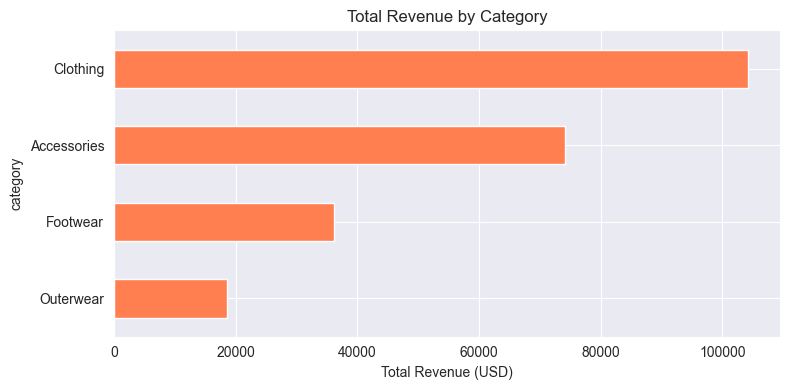

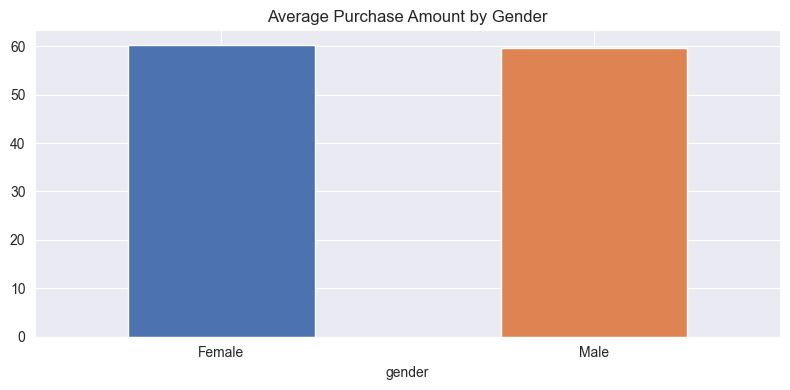

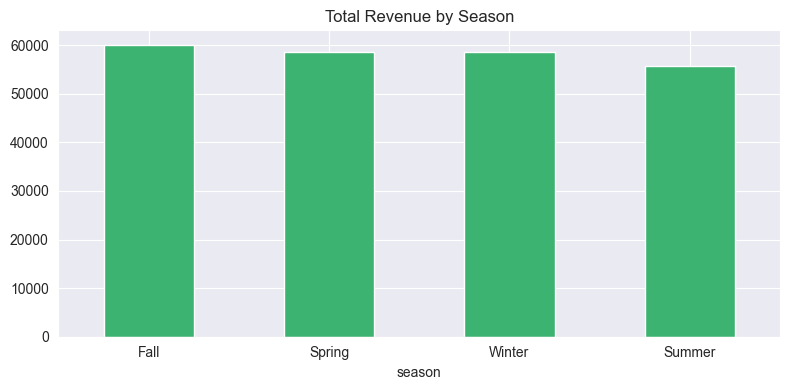

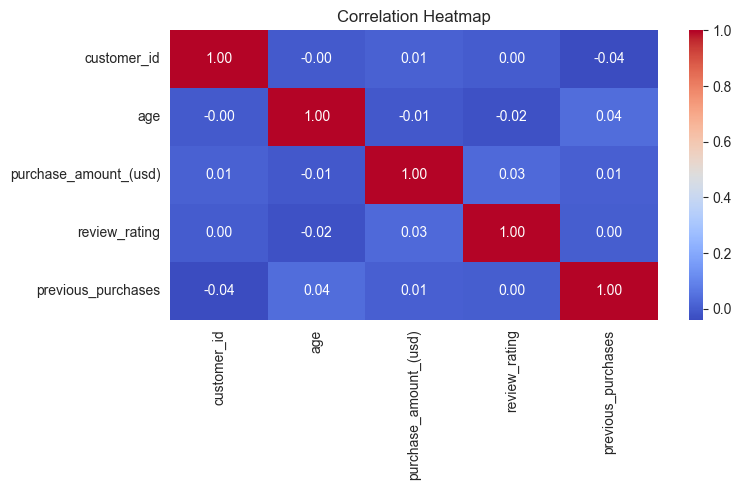

In [4]:
# Set the style for all charts
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8, 4)

# Chart 1 - Distribution of Purchase Amounts
plt.figure()
sns.histplot(df['purchase_amount_(usd)'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Purchase Amounts')
plt.xlabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

# Chart 2 - Total Revenue by Category
plt.figure()
df.groupby('category')['purchase_amount_(usd)'].sum().sort_values().plot(
    kind='barh', color='coral')
plt.title('Total Revenue by Category')
plt.xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

# Chart 3 - Avg Purchase Amount by Gender
plt.figure()
df.groupby('gender')['purchase_amount_(usd)'].mean().plot(
    kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Average Purchase Amount by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chart 4 - Revenue by Season
plt.figure()
df.groupby('season')['purchase_amount_(usd)'].sum().sort_values(ascending=False).plot(
    kind='bar', color='mediumseagreen')
plt.title('Total Revenue by Season')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chart 5 - Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [5]:
import pymysql

# Connect to MySQL
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='nadvi1998',  # Replace with your actual password
    database='customer_db'
)

cursor = conn.cursor()

# Drop and recreate table
cursor.execute("DROP TABLE IF EXISTS customer_shopping_behavior")
cursor.execute("""
    CREATE TABLE customer_shopping_behavior (
        customer_id INT,
        age INT,
        gender VARCHAR(10),
        item_purchased VARCHAR(50),
        category VARCHAR(50),
        purchase_amount_usd FLOAT,
        location VARCHAR(50),
        size VARCHAR(10),
        color VARCHAR(30),
        season VARCHAR(20),
        review_rating FLOAT,
        subscription_status VARCHAR(10),
        shipping_type VARCHAR(30),
        discount_applied VARCHAR(10),
        promo_code_used VARCHAR(10),
        previous_purchases INT,
        payment_method VARCHAR(30),
        frequency_of_purchases VARCHAR(30)
    )
""")

# Insert all rows at once
rows = [tuple(row) for _, row in df.iterrows()]
cursor.executemany("""
    INSERT INTO customer_shopping_behavior VALUES
    (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", rows)

conn.commit()
cursor.close()
conn.close()

print(f"✅ {len(rows)} rows pushed to MySQL successfully!")

ProgrammingError: nan can not be used with MySQL

In [6]:
import pymysql
import numpy as np

# Connect to MySQL
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='nadvi1998', 
    database='customer_db'
)

cursor = conn.cursor()

# Drop and recreate table
cursor.execute("DROP TABLE IF EXISTS customer_shopping_behavior")
cursor.execute("""
    CREATE TABLE customer_shopping_behavior (
        customer_id INT,
        age INT,
        gender VARCHAR(10),
        item_purchased VARCHAR(50),
        category VARCHAR(50),
        purchase_amount_usd FLOAT,
        location VARCHAR(50),
        size VARCHAR(10),
        color VARCHAR(30),
        season VARCHAR(20),
        review_rating FLOAT,
        subscription_status VARCHAR(10),
        shipping_type VARCHAR(30),
        discount_applied VARCHAR(10),
        promo_code_used VARCHAR(10),
        previous_purchases INT,
        payment_method VARCHAR(30),
        frequency_of_purchases VARCHAR(30)
    )
""")

# Replace NaN values with None (MySQL compatible)
df_clean = df.where(pd.notnull(df), None)

# Insert all rows at once
rows = [tuple(row) for _, row in df_clean.iterrows()]
cursor.executemany("""
    INSERT INTO customer_shopping_behavior VALUES
    (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", rows)

conn.commit()
cursor.close()
conn.close()

print(f"✅ {len(rows)} rows pushed to MySQL successfully!")

✅ 3900 rows pushed to MySQL successfully!
